In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Smart MCQ Solver Challenge
IITM BS Degree - Deep Learning & Generative AI

Name: VATSAL GUPTA

Roll Number: 23F3002118

In this project, I built a system to solve multiple-choice questions having one prompt and five options (A-E).

I used three different models:

1. TF-IDF + Logistic Regression - baseline model
2. BiLSTM + Attention - deep learning model built from scratch
3. BERT Multiple Choice - pretrained transformer model

Finally, I combined the predictions of these models using a weighted ensemble and selected the top 3 answers for Kaggle submission.

The main evaluation metric is MAP@3.

In [2]:
!pip install -q wandb transformers accelerate

import re
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

from transformers import AutoTokenizer, AutoModelForMultipleChoice
from torch.optim import AdamW

from collections import Counter
from tqdm.auto import tqdm

import wandb
from kaggle_secrets import UserSecretsClient


# keeping the same seed makes the results reproducible
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

**Connect W&B**

In [3]:
user_secrets = UserSecretsClient()
wandb_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=wandb_key)

print("W&B connected successfully")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f3002118 (23f3002118-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B connected successfully


**Load Dataset**

In [4]:
DATA_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge"

train = pd.read_csv(DATA_PATH + "/train.csv")
test = pd.read_csv(DATA_PATH + "/test.csv")
sample_submission = pd.read_csv(DATA_PATH + "/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())

Train shape: (2000, 8)
Test shape: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


**Cleaning and Label Encoding**

In [5]:
print("Missing values:")
print(train.isnull().sum())

print("\nAnswer distribution:")
print(train["answer"].value_counts())


def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


text_columns = ["prompt", "A", "B", "C", "D", "E"]

for col in text_columns:
    train[col] = train[col].apply(clean_text)
    test[col] = test[col].apply(clean_text)


label2id = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4}
id2label = {0: "A", 1: "B", 2: "C", 3: "D", 4: "E"}

train["label"] = train["answer"].map(label2id)

display(train.head())

Missing values:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Answer distribution:
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


,id,prompt,A,B,C,D,E,answer,label
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,1
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A,0
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C,2
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,1
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,0


**EDA Graphs**

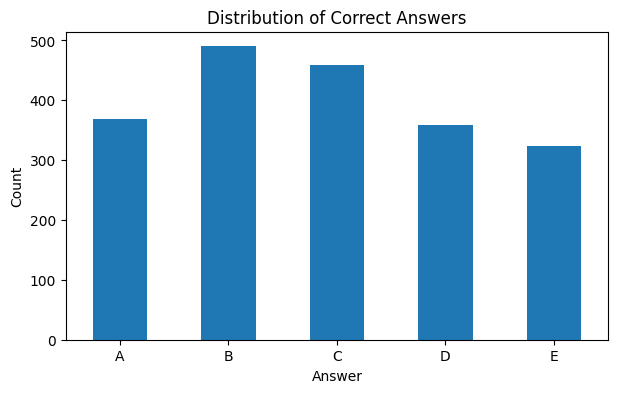

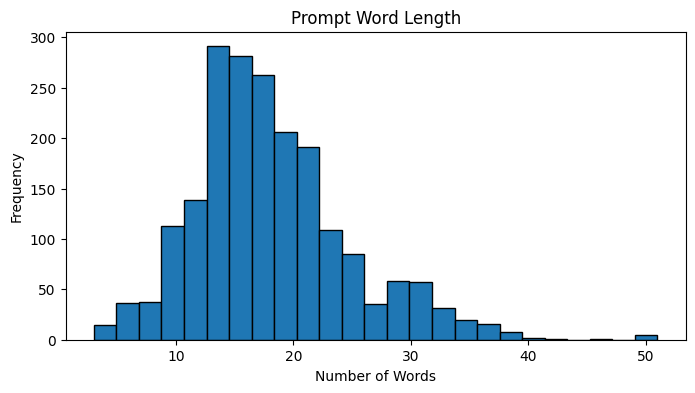

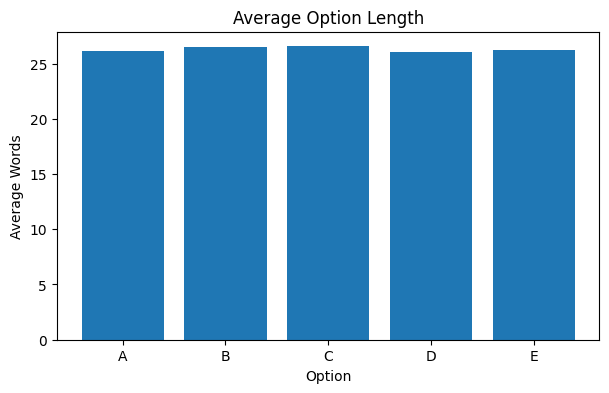

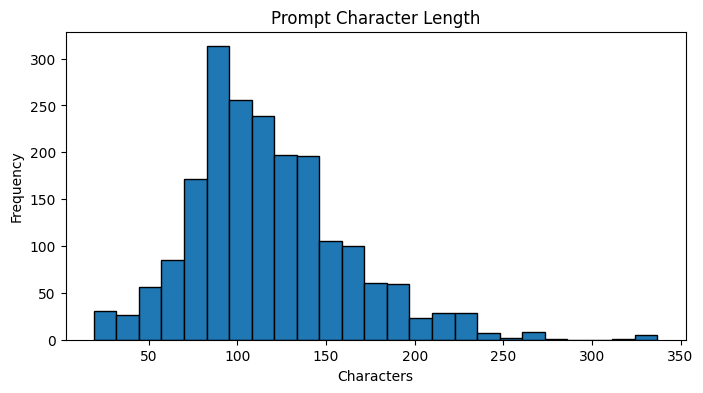

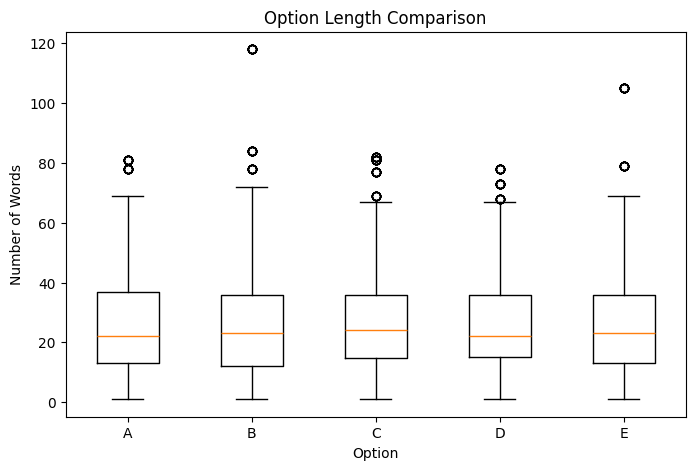

In [6]:
# Graph 1: Correct answer distribution
plt.figure(figsize=(7, 4))
train["answer"].value_counts().reindex(["A","B","C","D","E"]).plot(kind="bar")
plt.title("Distribution of Correct Answers")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


# Graph 2: Prompt word length
train["prompt_words"] = train["prompt"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
plt.hist(train["prompt_words"], bins=25, edgecolor="black")
plt.title("Prompt Word Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


# Graph 3: Average option length
average_option_lengths = [
    train[x].apply(lambda text: len(text.split())).mean()
    for x in ["A","B","C","D","E"]
]

plt.figure(figsize=(7, 4))
plt.bar(["A","B","C","D","E"], average_option_lengths)
plt.title("Average Option Length")
plt.xlabel("Option")
plt.ylabel("Average Words")
plt.show()


# Graph 4: Prompt character length
plt.figure(figsize=(8, 4))
plt.hist(train["prompt"].apply(len), bins=25, edgecolor="black")
plt.title("Prompt Character Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()


# Graph 5: Option length comparison
option_lengths = [
    train[x].apply(lambda text: len(text.split())).values
    for x in ["A","B","C","D","E"]
]

plt.figure(figsize=(8, 5))
plt.boxplot(option_lengths, tick_labels=["A","B","C","D","E"])
plt.title("Option Length Comparison")
plt.xlabel("Option")
plt.ylabel("Number of Words")
plt.show()

**Train/Validation Split + MAP@3**

In [7]:
train_df, val_df = train_test_split(
    train,
    test_size=0.20,
    random_state=SEED,
    stratify=train["answer"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))


def map_at_3(y_true, probabilities):
    top3 = np.argsort(probabilities, axis=1)[:, ::-1][:, :3]

    scores = []

    for actual, predicted in zip(y_true, top3):
        if actual == predicted[0]:
            scores.append(1.0)
        elif actual == predicted[1]:
            scores.append(0.5)
        elif actual == predicted[2]:
            scores.append(1/3)
        else:
            scores.append(0.0)

    return np.mean(scores)


def calculate_metrics(y_true, probabilities):
    predictions = np.argmax(probabilities, axis=1)

    accuracy = accuracy_score(y_true, predictions)
    macro_f1 = f1_score(y_true, predictions, average="macro")
    map3 = map_at_3(y_true, probabilities)

    return accuracy, macro_f1, map3


y_val = val_df["label"].values

Training samples: 1600
Validation samples: 400


**Model 1: TF-IDF**

In [8]:
def make_pair_dataset(df):
    texts = []
    labels = []

    for _, row in df.iterrows():
        for option in ["A","B","C","D","E"]:

            text = row["prompt"] + " [SEP] " + row[option]
            texts.append(text)

            labels.append(1 if option == row["answer"] else 0)

    return texts, np.array(labels)


tfidf_train_texts, tfidf_train_labels = make_pair_dataset(train_df)

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(tfidf_train_texts)

tfidf_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    C=2.0
)

tfidf_model.fit(X_train_tfidf, tfidf_train_labels)


def tfidf_predict(df):
    all_probs = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="TF-IDF"):

        texts = [
            row["prompt"] + " [SEP] " + row[x]
            for x in ["A","B","C","D","E"]
        ]

        features = tfidf.transform(texts)
        probs = tfidf_model.predict_proba(features)[:, 1]
        probs = probs / probs.sum()

        all_probs.append(probs)

    return np.array(all_probs)


tfidf_val_probs = tfidf_predict(val_df)

tfidf_acc, tfidf_f1, tfidf_map3 = calculate_metrics(
    y_val, tfidf_val_probs
)

print("TF-IDF Accuracy:", round(tfidf_acc, 4))
print("TF-IDF Macro F1:", round(tfidf_f1, 4))
print("TF-IDF MAP@3:", round(tfidf_map3, 4))

TF-IDF:   0%|          | 0/400 [00:00<?, ?it/s]

TF-IDF Accuracy: 0.975
TF-IDF Macro F1: 0.974
TF-IDF MAP@3: 0.9858


**TF-IDF W&B**

In [9]:
wandb.init(
    project="smart-mcq-solver",
    name="01_TFIDF_LogisticRegression"
)

wandb.log({
    "accuracy": tfidf_acc,
    "macro_f1": tfidf_f1,
    "map3": tfidf_map3
})

wandb.finish()

wandb: setting up run r09z1o9z
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260730_161316-r09z1o9z
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run 01_TFIDF_LogisticRegression
wandb: ⭐️ View project at https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver
wandb: 🚀 View run at https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver/runs/r09z1o9z
wandb: updating run metadata; uploading summary
wandb: uploading summary
wandb: uploading summary; uploading requirements.txt
wandb: uploading summary
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb: accuracy ▁
wandb: macro_f1 ▁
wandb:     map3 ▁
wandb: 
wandb: Run summary:
wandb: accuracy 0.975
wandb: macro_f1 0.974
wandb:     map3 0.98583
wandb: 
wandb: 🚀 View run 01_TFIDF_LogisticRegression at: https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver/

**BiLSTM Data Preparation**

In [10]:
word_counter = Counter()

for col in text_columns:
    for text in train_df[col]:
        word_counter.update(text.lower().split())


MAX_VOCAB = 25000

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in word_counter.most_common(MAX_VOCAB - 2):
    word2idx[word] = len(word2idx)


MAX_LEN = 100


def encode_text(text):
    words = text.lower().split()
    ids = [word2idx.get(word, 1) for word in words]
    return ids[:MAX_LEN]


class BiLSTMDataset(Dataset):

    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        choices = []

        for option in ["A","B","C","D","E"]:
            text = row["prompt"] + " " + row[option]
            ids = encode_text(text)
            choices.append(torch.tensor(ids, dtype=torch.long))

        return choices, int(row["label"])


def bilstm_collate(batch):
    sequences = []
    labels = []

    for choices, label in batch:
        sequences.extend(choices)
        labels.append(label)

    sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0
    )

    sequences = sequences.view(len(batch), 5, -1)
    labels = torch.tensor(labels, dtype=torch.long)

    return sequences, labels


bilstm_train_loader = DataLoader(
    BiLSTMDataset(train_df),
    batch_size=32,
    shuffle=True,
    collate_fn=bilstm_collate
)

bilstm_val_loader = DataLoader(
    BiLSTMDataset(val_df),
    batch_size=64,
    shuffle=False,
    collate_fn=bilstm_collate
)

**BiLSTM + Attention Model**

In [11]:
class BiLSTMAttention(nn.Module):

    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.classifier = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):

        batch_size, choices, seq_len = x.shape
        x = x.view(batch_size * choices, seq_len)

        mask = x != 0

        x = self.embedding(x)
        output, _ = self.lstm(x)

        attention_scores = self.attention(output).squeeze(-1)
        attention_scores = attention_scores.masked_fill(~mask, -1e9)

        attention_weights = torch.softmax(attention_scores, dim=1)

        context = torch.sum(
            output * attention_weights.unsqueeze(-1),
            dim=1
        )

        scores = self.classifier(context)

        return scores.view(batch_size, choices)


bilstm_model = BiLSTMAttention(len(word2idx)).to(device)

criterion = nn.CrossEntropyLoss()

bilstm_optimizer = torch.optim.Adam(
    bilstm_model.parameters(),
    lr=0.001
)

print(bilstm_model)

BiLSTMAttention(
  (embedding): Embedding(3815, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=256, out_features=1, bias=True)
  (classifier): Linear(in_features=256, out_features=1, bias=True)
)


**Train BiLSTM + W&B**

In [12]:
def evaluate_bilstm(model, loader):

    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:

            x = x.to(device)

            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_labels.extend(y.numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.array(all_labels)

    acc, f1, map3 = calculate_metrics(all_labels, all_probs)

    return acc, f1, map3, all_probs


BILSTM_EPOCHS = 8

wandb.init(
    project="smart-mcq-solver",
    name="02_BiLSTM_Attention"
)

best_bilstm_map3 = 0
bilstm_loss_history = []
bilstm_map_history = []


for epoch in range(BILSTM_EPOCHS):

    bilstm_model.train()
    total_loss = 0

    for x, y in tqdm(
        bilstm_train_loader,
        desc=f"Epoch {epoch+1}"
    ):

        x = x.to(device)
        y = y.to(device)

        bilstm_optimizer.zero_grad()

        logits = bilstm_model(x)
        loss = criterion(logits, y)

        loss.backward()
        bilstm_optimizer.step()

        total_loss += loss.item()


    train_loss = total_loss / len(bilstm_train_loader)

    val_acc, val_f1, val_map3, bilstm_val_probs = evaluate_bilstm(
        bilstm_model,
        bilstm_val_loader
    )

    bilstm_loss_history.append(train_loss)
    bilstm_map_history.append(val_map3)

    print(
        f"Epoch {epoch+1} | Loss {train_loss:.4f} | "
        f"Accuracy {val_acc:.4f} | F1 {val_f1:.4f} | "
        f"MAP@3 {val_map3:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "val_map3": val_map3
    })

    if val_map3 > best_bilstm_map3:
        best_bilstm_map3 = val_map3

        torch.save(
            bilstm_model.state_dict(),
            "/kaggle/working/best_bilstm.pt"
        )


wandb.finish()


bilstm_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_bilstm.pt",
        map_location=device
    )
)

bilstm_acc, bilstm_f1, bilstm_map3, bilstm_val_probs = evaluate_bilstm(
    bilstm_model,
    bilstm_val_loader
)

print("BiLSTM Accuracy:", round(bilstm_acc, 4))
print("BiLSTM Macro F1:", round(bilstm_f1, 4))
print("BiLSTM MAP@3:", round(bilstm_map3, 4))

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: setting up run 197hewea
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260730_161428-197hewea
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run 02_BiLSTM_Attention
wandb: ⭐️ View project at https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver
wandb: 🚀 View run at https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver/runs/197hewea


Epoch 1:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1 | Loss 1.3488 | Accuracy 0.7700 | F1 0.7698 | MAP@3 0.8533


Epoch 2:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2 | Loss 0.5162 | Accuracy 0.9375 | F1 0.9344 | MAP@3 0.9604


...

Epoch 8:   0%|          | 0/50 [00:00<?, ?it/s]

wandb: uploading summary; updating run metadata


Epoch 8 | Loss 0.0107 | Accuracy 0.9975 | F1 0.9974 | MAP@3 0.9988


wandb: uploading summary
wandb: uploading summary; uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading summary
wandb: uploading history steps 0-7, summary, console lines 0-7
wandb: 
wandb: Run history:
wandb:        epoch ▁▂▃▄▅▆▇█
wandb:   train_loss █▄▂▁▁▁▁▁
wandb: val_accuracy ▁▆██████
wandb: val_macro_f1 ▁▆██████
wandb:     val_map3 ▁▆██████
wandb: 
wandb: Run summary:
wandb:        epoch 8
wandb:   train_loss 0.0107
wandb: val_accuracy 0.9975
wandb: val_macro_f1 0.99737
wandb:     val_map3 0.99875
wandb: 
wandb: 🚀 View run 02_BiLSTM_Attention at: https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver/runs/197hewea
wandb: ⭐️ View project at: https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260730_161428-197hewea/logs


BiLSTM Accuracy: 0.9975
BiLSTM Macro F1: 0.9974
BiLSTM MAP@3: 0.9988


**BiLSTM Training Graphs**

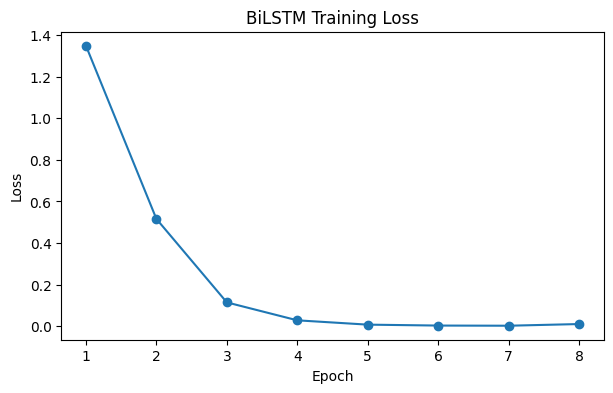

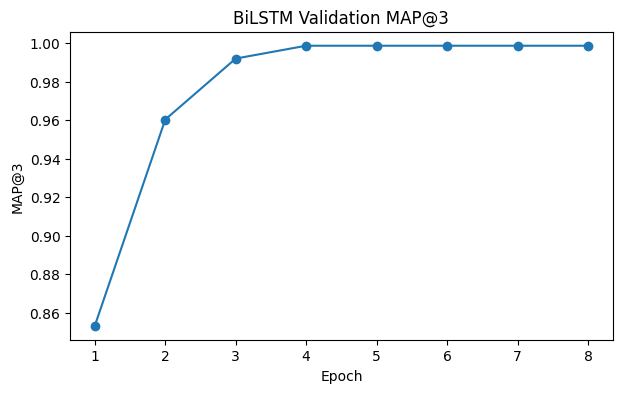

In [13]:
plt.figure(figsize=(7,4))
plt.plot(range(1, BILSTM_EPOCHS+1), bilstm_loss_history, marker="o")
plt.title("BiLSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


plt.figure(figsize=(7,4))
plt.plot(range(1, BILSTM_EPOCHS+1), bilstm_map_history, marker="o")
plt.title("BiLSTM Validation MAP@3")
plt.xlabel("Epoch")
plt.ylabel("MAP@3")
plt.show()

**BERT Dataset**

In [14]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class BertMCQDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length=128, training=True):

        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        prompts = [row["prompt"]] * 5
        choices = [row["A"], row["B"], row["C"], row["D"], row["E"]]

        encoding = self.tokenizer(
            prompts,
            choices,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            "input_ids": encoding["input_ids"],
            "attention_mask": encoding["attention_mask"]
        }

        if "token_type_ids" in encoding:
            item["token_type_ids"] = encoding["token_type_ids"]

        if self.training:
            item["labels"] = torch.tensor(
                int(row["label"]),
                dtype=torch.long
            )

        return item


bert_train_loader = DataLoader(
    BertMCQDataset(train_df, tokenizer),
    batch_size=8,
    shuffle=True
)

bert_val_loader = DataLoader(
    BertMCQDataset(val_df, tokenizer),
    batch_size=16,
    shuffle=False
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

**BERT Model + Training**

In [15]:
bert_model = AutoModelForMultipleChoice.from_pretrained(
    MODEL_NAME
).to(device)

bert_optimizer = AdamW(
    bert_model.parameters(),
    lr=2e-5
)


def evaluate_bert(model, loader):

    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():

        for batch in tqdm(loader, desc="BERT validation"):

            all_labels.extend(batch["labels"].numpy())

            inputs = {
                key: value.to(device)
                for key, value in batch.items()
                if key != "labels"
            }

            outputs = model(**inputs)

            probs = torch.softmax(
                outputs.logits,
                dim=1
            )

            all_probs.append(probs.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.array(all_labels)

    acc, f1, map3 = calculate_metrics(
        all_labels,
        all_probs
    )

    return acc, f1, map3, all_probs


BERT_EPOCHS = 2

wandb.init(
    project="smart-mcq-solver",
    name="03_BERT_MultipleChoice"
)

best_bert_map3 = 0
bert_loss_history = []
bert_map_history = []


for epoch in range(BERT_EPOCHS):

    bert_model.train()
    total_loss = 0

    for batch in tqdm(
        bert_train_loader,
        desc=f"BERT Epoch {epoch+1}"
    ):

        labels = batch["labels"].to(device)

        inputs = {
            key: value.to(device)
            for key, value in batch.items()
            if key != "labels"
        }

        bert_optimizer.zero_grad()

        outputs = bert_model(
            **inputs,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            bert_model.parameters(),
            1.0
        )

        bert_optimizer.step()

        total_loss += loss.item()


    train_loss = total_loss / len(bert_train_loader)

    bert_acc, bert_f1, bert_map3, bert_val_probs = evaluate_bert(
        bert_model,
        bert_val_loader
    )

    bert_loss_history.append(train_loss)
    bert_map_history.append(bert_map3)

    print(
        f"Epoch {epoch+1} | Loss {train_loss:.4f} | "
        f"Accuracy {bert_acc:.4f} | F1 {bert_f1:.4f} | "
        f"MAP@3 {bert_map3:.4f}"
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_accuracy": bert_acc,
        "val_macro_f1": bert_f1,
        "val_map3": bert_map3
    })

    if bert_map3 > best_bert_map3:

        best_bert_map3 = bert_map3

        torch.save(
            bert_model.state_dict(),
            "/kaggle/working/best_bert.pt"
        )


wandb.finish()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wandb: setting up run opm8ods0
wandb: Trackin

BERT Epoch 1:   0%|          | 0/200 [00:00<?, ?it/s]

BERT validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1 | Loss 1.3627 | Accuracy 0.8825 | F1 0.8790 | MAP@3 0.9242


BERT Epoch 2:   0%|          | 0/200 [00:00<?, ?it/s]

BERT validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 2 | Loss 0.4680 | Accuracy 0.9800 | F1 0.9792 | MAP@3 0.9896


wandb: updating run metadata
wandb: uploading history steps 1-1, summary, console lines 1-1
wandb: 
wandb: Run history:
wandb:        epoch ▁█
wandb:   train_loss █▁
wandb: val_accuracy ▁█
wandb: val_macro_f1 ▁█
wandb:     val_map3 ▁█
wandb: 
wandb: Run summary:
wandb:        epoch 2
wandb:   train_loss 0.46803
wandb: val_accuracy 0.98
wandb: val_macro_f1 0.97923
wandb:     val_map3 0.98958
wandb: 
wandb: 🚀 View run 03_BERT_MultipleChoice at: https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver/runs/opm8ods0
wandb: ⭐️ View project at: https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260730_161450-opm8ods0/logs


**Load Best BERT + Results**

BERT validation:   0%|          | 0/25 [00:00<?, ?it/s]

BERT Accuracy: 0.98
BERT Macro F1: 0.9792
BERT MAP@3: 0.9896


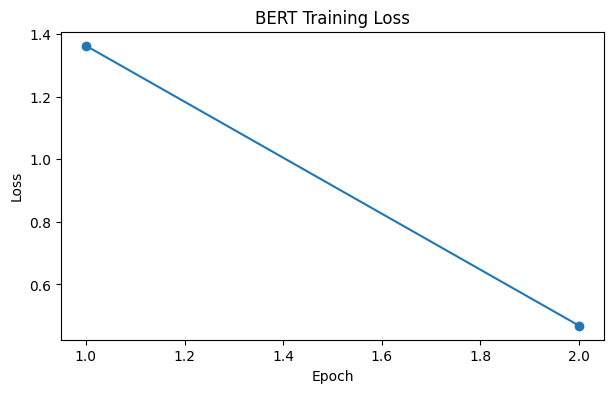

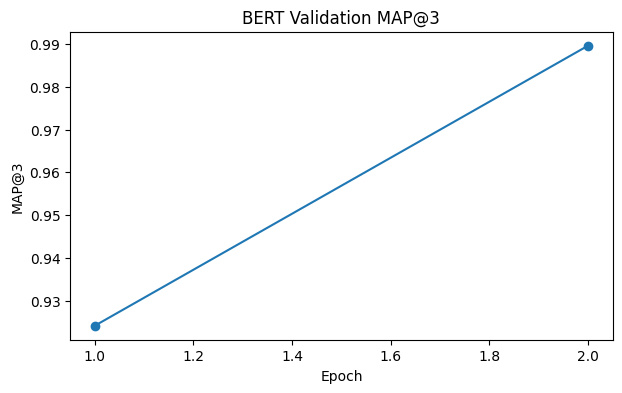

In [16]:
bert_model.load_state_dict(
    torch.load(
        "/kaggle/working/best_bert.pt",
        map_location=device
    )
)

bert_acc, bert_f1, bert_map3, bert_val_probs = evaluate_bert(
    bert_model,
    bert_val_loader
)

print("BERT Accuracy:", round(bert_acc, 4))
print("BERT Macro F1:", round(bert_f1, 4))
print("BERT MAP@3:", round(bert_map3, 4))


plt.figure(figsize=(7,4))
plt.plot(range(1, BERT_EPOCHS+1), bert_loss_history, marker="o")
plt.title("BERT Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


plt.figure(figsize=(7,4))
plt.plot(range(1, BERT_EPOCHS+1), bert_map_history, marker="o")
plt.title("BERT Validation MAP@3")
plt.xlabel("Epoch")
plt.ylabel("MAP@3")
plt.show()

**Ensemble**

In [17]:
ensemble_val_probs = (
    0.15 * tfidf_val_probs
    + 0.25 * bilstm_val_probs
    + 0.60 * bert_val_probs
)

ensemble_acc, ensemble_f1, ensemble_map3 = calculate_metrics(
    y_val,
    ensemble_val_probs
)

print("Ensemble Accuracy:", round(ensemble_acc, 4))
print("Ensemble Macro F1:", round(ensemble_f1, 4))
print("Ensemble MAP@3:", round(ensemble_map3, 4))


wandb.init(
    project="smart-mcq-solver",
    name="04_Weighted_Ensemble"
)

wandb.log({
    "accuracy": ensemble_acc,
    "macro_f1": ensemble_f1,
    "map3": ensemble_map3
})

wandb.finish()

Ensemble Accuracy: 0.9975
Ensemble Macro F1: 0.9974
Ensemble MAP@3: 0.9988


wandb: setting up run 83me9mak
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260730_162139-83me9mak
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run 04_Weighted_Ensemble
wandb: ⭐️ View project at https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver
wandb: 🚀 View run at https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver/runs/83me9mak
wandb: updating run metadata; uploading summary
wandb: uploading summary
wandb: uploading summary; uploading config.yaml
wandb: uploading summary
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb: accuracy ▁
wandb: macro_f1 ▁
wandb:     map3 ▁
wandb: 
wandb: Run summary:
wandb: accuracy 0.9975
wandb: macro_f1 0.99737
wandb:     map3 0.99875
wandb: 
wandb: 🚀 View run 04_Weighted_Ensemble at: https://wandb.ai/23f3002118-indian-institute-of-technology-madras/smart-mcq-solver/runs/83me9mak
wa

**Compare All Models**

,Model,Accuracy,Macro F1,MAP@3
0,TF-IDF + Logistic Regression,0.9750,0.9740,0.9858
1,BiLSTM + Attention,0.9975,0.9974,0.9988
2,Pretrained BERT,0.9800,0.9792,0.9896
3,Weighted Ensemble,0.9975,0.9974,0.9988


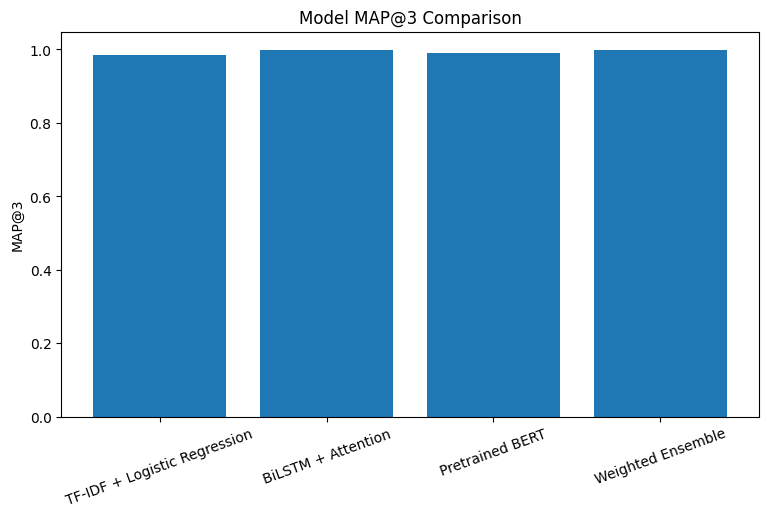

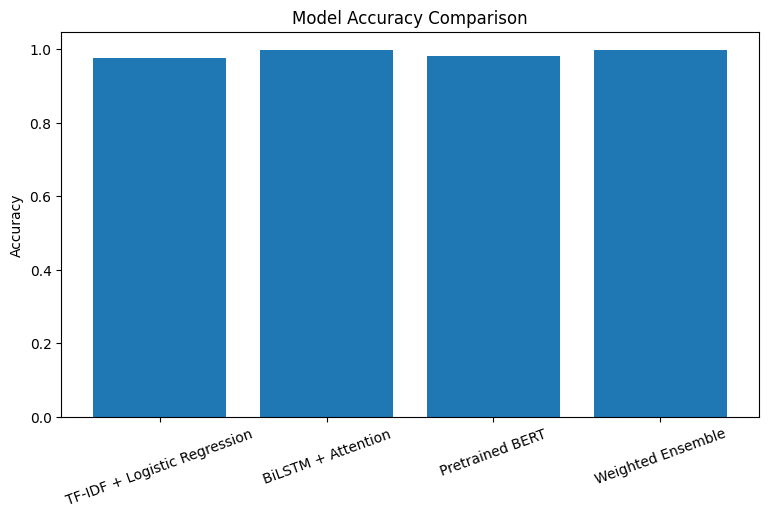

In [18]:
results = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "BiLSTM + Attention",
        "Pretrained BERT",
        "Weighted Ensemble"
    ],

    "Accuracy": [
        tfidf_acc,
        bilstm_acc,
        bert_acc,
        ensemble_acc
    ],

    "Macro F1": [
        tfidf_f1,
        bilstm_f1,
        bert_f1,
        ensemble_f1
    ],

    "MAP@3": [
        tfidf_map3,
        bilstm_map3,
        bert_map3,
        ensemble_map3
    ]
})

display(results.round(4))


plt.figure(figsize=(9,5))
plt.bar(results["Model"], results["MAP@3"])
plt.title("Model MAP@3 Comparison")
plt.ylabel("MAP@3")
plt.xticks(rotation=20)
plt.show()


plt.figure(figsize=(9,5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

**Test Prediction Functions**

In [19]:
# BiLSTM test loader
test_bilstm = test.copy()
test_bilstm["label"] = 0

bilstm_test_loader = DataLoader(
    BiLSTMDataset(test_bilstm),
    batch_size=64,
    shuffle=False,
    collate_fn=bilstm_collate
)


def predict_bilstm_test():

    bilstm_model.eval()
    all_probs = []

    with torch.no_grad():

        for x, _ in tqdm(
            bilstm_test_loader,
            desc="BiLSTM test"
        ):

            x = x.to(device)

            logits = bilstm_model(x)
            probs = torch.softmax(logits, dim=1)

            all_probs.append(probs.cpu().numpy())

    return np.vstack(all_probs)


# BERT test loader
bert_test_dataset = BertMCQDataset(
    test,
    tokenizer,
    training=False
)

bert_test_loader = DataLoader(
    bert_test_dataset,
    batch_size=16,
    shuffle=False
)


def predict_bert_test():

    bert_model.eval()
    all_probs = []

    with torch.no_grad():

        for batch in tqdm(
            bert_test_loader,
            desc="BERT test"
        ):

            inputs = {
                key: value.to(device)
                for key, value in batch.items()
            }

            outputs = bert_model(**inputs)

            probs = torch.softmax(
                outputs.logits,
                dim=1
            )

            all_probs.append(probs.cpu().numpy())

    return np.vstack(all_probs)

**Submission**

In [20]:
tfidf_test_probs = tfidf_predict(test)
bilstm_test_probs = predict_bilstm_test()
bert_test_probs = predict_bert_test()


final_probs = (
    0.15 * tfidf_test_probs
    + 0.25 * bilstm_test_probs
    + 0.60 * bert_test_probs
)


top3_indices = np.argsort(
    final_probs,
    axis=1
)[:, ::-1][:, :3]


predictions = []

for row in top3_indices:

    letters = [
        id2label[int(index)]
        for index in row
    ]

    predictions.append(" ".join(letters))


submission = sample_submission.copy()
submission["Prediction"] = predictions

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

display(submission.head(10))

print("submission.csv created successfully")

TF-IDF:   0%|          | 0/500 [00:00<?, ?it/s]

BiLSTM test:   0%|          | 0/8 [00:00<?, ?it/s]

BERT test:   0%|          | 0/32 [00:00<?, ?it/s]

,ID,Prediction
0,1,A E B
1,2,B A D
2,3,B E D
3,4,E C D
4,5,C A B
5,6,D A B
6,7,E D C
7,8,B E A
8,9,C D E
9,10,B E C


submission.csv created successfully


**Error Analysis**

In [21]:
ensemble_predictions = np.argmax(
    ensemble_val_probs,
    axis=1
)

wrong_indices = np.where(
    ensemble_predictions != y_val
)[0]

print("Wrong validation predictions:", len(wrong_indices))


for index in wrong_indices[:5]:

    row = val_df.iloc[index]

    predicted_letter = id2label[
        ensemble_predictions[index]
    ]

    print("\nQuestion:", row["prompt"])

    print(
        "Correct:",
        row["answer"],
        "-",
        row[row["answer"]]
    )

    print(
        "Predicted:",
        predicted_letter,
        "-",
        row[predicted_letter]
    )

Wrong validation predictions: 1

Question: Determine the correct option: What is geometric quantization in mathematical physics? among the listed options.
Correct: E - Geometric quantization is a mathematical approach to defining a quantum framework corresponding to a given classical framework. It attempts to carry out quantization in such a way that certain analogies between the classical framework and the quantum framework remain manifest.
Predicted: C - Geometric quantization is a mathematical approach to defining a classical principle corresponding to a given quantum principle. It attempts to carry out quantization in such a way that certain analogies between the quantum principle and the classical principle remain manifest.
